<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/7.0%20Retention_Priority_Matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sqlalchemy import inspect, text,create_engine
from google.colab import drive
from google.colab import userdata

drive.mount('/content/drive')

clustering_model = joblib.load('/content/drive/MyDrive/clustering_model.joblib')
churn_model = joblib.load('/content/drive/MyDrive/churn_model.joblib')
frequency_model = joblib.load('/content/drive/MyDrive/frequency_regression_model.joblib')
aov_model = joblib.load('/content/drive/MyDrive/aov_regression_model.joblib')

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

metrics_query = """
SELECT "CustomerID",
    SUM("Revenue") AS "TotalRevenue",
    AVG("Revenue") AS "AOV",
    MAX("InvoiceDate") - MIN("InvoiceDate") AS "ObservedLifeSpan",
    (SELECT MAX("InvoiceDate")
    FROM v_clean_sales_analytics) - MAX("InvoiceDate") AS "Recency",
    (SELECT MAX("InvoiceDate")
    FROM v_clean_sales_analytics) - MIN("InvoiceDate") AS "Tenure",
     COUNT(DISTINCT "StockCode") AS "ProductDiversity",
    COUNT(DISTINCT "InvoiceDate") AS "Frequency",
    TO_CHAR(MIN("InvoiceDate"), 'YYYY-MM') AS "CohortMonth"

FROM v_clean_sales_analytics
-- WHERE "InvoiceDate" > '2011-08-31'
GROUP BY "CustomerID"
"""

metrics_df = pd.read_sql(text(metrics_query), con = engine)

rfm_query = """WITH metrics AS
(SELECT "CustomerID",
    (SELECT MAX("InvoiceDate")
    FROM v_clean_sales_analytics) - MAX("InvoiceDate") AS "Recency",
    COUNT(DISTINCT "InvoiceDate") AS "Frequency",
    SUM("Revenue") AS "Monetary"
FROM v_clean_sales_analytics
WHERE "InvoiceDate" > '2011-08-31'
GROUP BY "CustomerID"),

rfm_scores AS
(SELECT "CustomerID",
    NTILE(5) OVER(ORDER BY "Recency" DESC) AS "R",
    NTILE(5) OVER(ORDER BY "Frequency" ASC) AS "F",
    NTILE(5) OVER(ORDER BY "Monetary" ASC) AS "M"
FROM metrics)

SELECT *,
    "R" + "F" + "M" AS "RfmScore"
FROM rfm_scores
"""

rfm_df = pd.read_sql(text(rfm_query), con = engine)

#Predicting churn labels
def customer_predictions(metrics_df):

    feature_cols = [
    "Tenure",
    "ObservedLifeSpan",
    "TotalRevenue",
    "Recency",
    "ProductDiversity",
    "Frequency"]

    X = metrics_df[feature_cols]
    X = pd.get_dummies(X, drop_first = True)

    metrics_df['KSegment'] = clustering_model.predict(X)

    persona_mapping = {
        3: "Low Engagement Risk Group",
        1: "Loyal Performers",
        0: "Lost & Inactive Customers",
        2: "High-Value Elite"
    }

    metrics_df['KSegment'] = metrics_df['KSegment'].map(persona_mapping)

    #Feature order
    feature_cols = ['Recency', 'Frequency', 'TotalRevenue', 'ObservedLifeSpan', 'Tenure',
       'ProductDiversity']

    X = metrics_df[feature_cols]
    X = pd.get_dummies(X, drop_first = True)

    #Predicting churn labels
    metrics_df['ChurnProbability'] = churn_model.predict_proba(X)[:,1]
    metrics_df['ChurnLabel'] = churn_model.predict(X)

    feature_cols = ['Frequency','Recency', 'TotalRevenue', 'ObservedLifeSpan', 'Tenure',
    'ProductDiversity']
    X = metrics_df[feature_cols]
    X = pd.get_dummies(X, drop_first = True)

    #Predicting frequency
    metrics_df['PredictedFrequency'] = frequency_model.predict(X)

    #Predicting aov
    metrics_df['PredictedAOV'] = aov_model.predict(X)

    metrics_df['PredictedCLTV'] = metrics_df['PredictedFrequency'] * metrics_df['PredictedAOV']
    return metrics_df

customer_predictions(metrics_df)

#Exporting dataframes to database table
metrics_df.to_sql(
    name = 'production_predictions',
    con = engine,
    if_exists = 'replace',
    index = False
)

rfm_df.to_sql(
    name = 'production_rfm',
    con = engine,
    if_exists = 'replace',
    index = False
)

metrics_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,TotalRevenue,AOV,ObservedLifeSpan,Recency,Tenure,ProductDiversity,Frequency,CohortMonth,KSegment,ChurnProbability,ChurnLabel,PredictedFrequency,PredictedAOV,PredictedCLTV
0,12346.0,77183.60,77183.600000,0,325,325,1,1,2011-01,High-Value Elite,0.998192,1,0.300838,11.425697,3.437279
1,12347.0,4310.00,23.681319,365,2,367,103,7,2010-12,High-Value Elite,0.000569,0,2.136593,25.786854,55.096005
2,12348.0,1797.24,57.975484,283,75,358,22,4,2010-12,Loyal Performers,0.032340,0,1.083336,22.521014,24.397835
3,12349.0,1757.55,24.076027,0,18,18,73,1,2011-11,Low Engagement Risk Group,0.009035,0,0.888102,3.743127,3.324280
4,12350.0,334.40,19.670588,0,310,310,17,1,2011-02,Lost & Inactive Customers,0.997806,1,0.315104,0.071371,0.022489


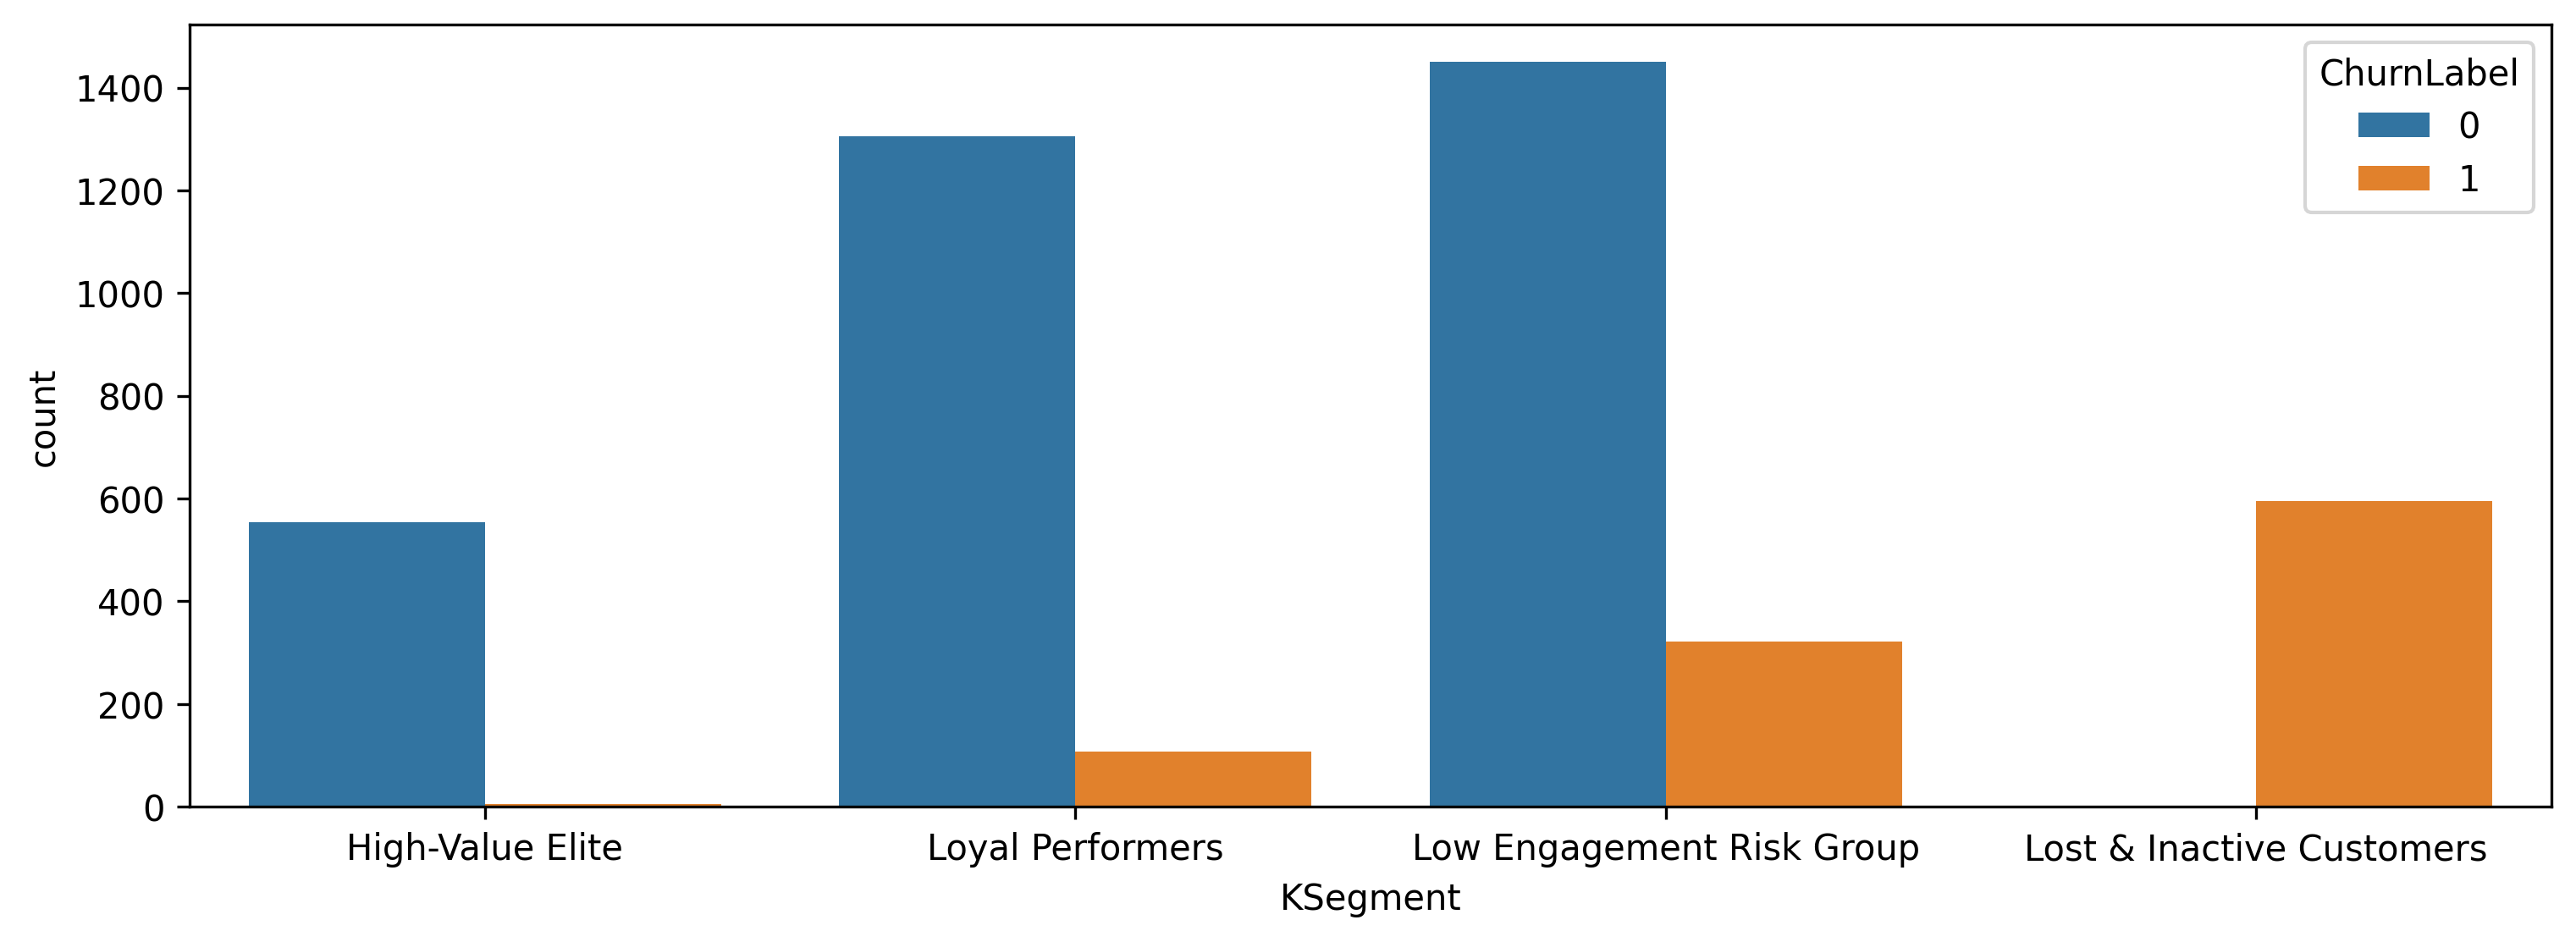

KSegment,High-Value Elite,Lost & Inactive Customers,Low Engagement Risk Group,Loyal Performers
ChurnLabel,,,,
0,554.0,0.0,1450.0,1306.0
1,5.0,595.0,321.0,108.0
AtRiskPercent,0.89%,100.0%,18.13%,7.64%


In [122]:
plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = metrics_df, x = 'KSegment', hue = 'ChurnLabel')
plt.show()

summary =  metrics_df.groupby(['KSegment', 'ChurnLabel']).size().unstack().fillna(0)
summary['AtRiskPercent'] = round((summary[1]/(summary[0] + summary[1])*100),2).astype('str') + '%'
summary.transpose()

In [123]:
metrics_df.query('ChurnLabel != 0').groupby('KSegment')[['PredictedCLTV', 'ChurnProbability']].agg(
    customer_count = ('PredictedCLTV', 'count'),
    revenue_at_risk = ('PredictedCLTV', 'sum')
    #,avg_churn_probability = ('ChurnProbability', 'min')
    ).round()

,customer_count,revenue_at_risk
KSegment,,
High-Value Elite,5,35.0
Lost & Inactive Customers,595,309.0
Low Engagement Risk Group,321,297.0
Loyal Performers,108,274.0
